<div class="alert alert-info">
    <h1>Analysis of Saturn's F Ring During the Cassini Mission</h1>
    <h1>Do We Need to Adjust for Single-Scattering and Shadowing?</h1>

Robert S. French, rfrench@seti.org - Last updated January 8, 2026

Research performed under NASA Grant 80NSSC21K0527 for CDAP proposal "The Recent History of Saturn's Dusty Rings".
<h2>The Problem</h2>

<ul>
<li>French (2012) plotted low-phase angle (&lt; 60 degrees) Normal EWs and found that observations taken with
    the emission angle or incidence angle within 6 degrees of the ring plane were systematically less
    bright than other observation (see their Figure 6a).</li>
    
<li>French (2012) used this as justification for needing to adjust all measurements for single-scattering
    and shadowing using formulas from Chandrasekhar (see their Appendix).</li>
    
<li>By minimizing the scatter of all points around a log-cubic phase curve (with the large clump of 2006 removed), they derived an "equivalent tau" optical depth of 0.033. All measurements were adjusted using the Chandrasekhar formula based on this tau.</li>
    
<li>The end result was that the ring appeared brighter, because accounting for single-scattering and shadowing
    made each point brighter.</li>
    
<li><b>Do we still need to do this?</b></li>
</ul>
    
<h2>Methodology</h2>

<ol>
<li>Reproduce Fig 6a using original 2012 data to verify reproduceability. Also optimize for tau.</li>
    
<li>Reproduce Fig 6a using original 2012 data adjusted for known differences in calibration to see if the new calibration is primarily responsible for the observed effect. Also optimize for tau.</li>

<li>Reproduce Fig 6a using new data (limited to 2012 observations) to see what changes the other processing changes caused. Also optimize for tau. If the calibration factors are accurate, we expect this to give the same answer as step 2.</li>

<li>Create a new equivalent figure using ALL new low-phase observations with means. Also optimize for tau.</li>

<li>Create a new equivalent figure using ALL new low-phase observations with 1-degree slices. Also optimize for tau.</li>
    
<li>Repeat experiment 4 using only observations (incidence AND emission) more than 4 degrees from the ring plane.</li>

<li>Repeat experiment 5 using only observations (incidence AND emission) more than 4 degrees from the ring plane.</li>
    
<li>Fit a phase curve for ALL new observations optimizing for tau.</li>

<li>Fit a phase curve for ALL new observations using 1-degree slices optimizing for tau.</li>

<li>Repeat experiment 8 using only observations (incidence AND emission) more than 4 degrees from the ring plane.</li>

<li>Repeat experiment 9 using only observations (incidence AND emission) more than 4 degrees from the ring plane.</li>

<li>Using the full-data phase curve, plot EW 1-Degree Slices/Phase Curve vs. Mu and Mu0 and look for trends.</li>

<li>Using the full-data phase curve and phase angles < 60, plot EW 1-Degree Slices/Phase Curve vs. Mu and Mu0 and look for trends.</li>
    
<li>Decide if the adjustment is still required.</li>
</ul>
</div>

# Read Data and Initialize Data Structures

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd
import sys
if '..' not in sys.path: sys.path.append('..'); sys.path.append('../external')

from f_ring_util.f_ring import (add_cisscal_ratios,
                                add_hover,
                                compute_corrected_ew_col,
                                find_common_data_2012,
                                fit_hg_phase_function,
                                hg_func,
                                limit_by_quant,
                                print_hg_params,
                                read_ew_stats)

%matplotlib widget
mpl.rcParams['figure.max_open_warning'] = 100

In [25]:
### PLOTTING AND OPTIMIZATION

def _standard_alpha(obsdata):
    """Return alpha based on number of points to plot."""
    if len(obsdata) < 1000:
        return 1
    elif len(obsdata) < 10000:
        return 0.6
    else:
        return 0.3
        
def compare_tau_no_tau_60(obsdata, col='Normal EW Mean', small_plot=False, use_2012_limits=False, best_tau=None):
    low_phase = obsdata['Mean Phase'] <= 60
    low_phase_obsdata = obsdata[low_phase]
    low_e = np.abs(low_phase_obsdata['Mean Emission'].to_numpy()-90) < 6
    low_i = np.abs(low_phase_obsdata['Incidence'].to_numpy()-90) < 6
    low_ei = low_e | low_i

    best_ratio = None
    if best_tau is None:
        best_ratio = 1e38
        for tau in np.arange(0, 0.04, 0.001):
            corrected_ew = compute_corrected_ew_col(low_phase_obsdata, col_tau=(col, tau))
            mean_low_tau = np.mean(corrected_ew[low_ei])
            mean_notlow_tau = np.mean(corrected_ew[~low_ei])
            ratio = mean_low_tau / mean_notlow_tau
            if ratio < 1:
                ratio = 1/ratio
            if ratio < best_ratio:
                best_ratio = ratio
                best_tau = tau
    #         print(f'{tau:.3f}: {ratio:.5f}')
    #     print()

    mean_low = np.mean(low_phase_obsdata[col][low_ei])
    mean_notlow = np.mean(low_phase_obsdata[col][~low_ei])
    print('NO TAU:')
    print(f'Mean Normal EW low E/I: {mean_low:.3f}')
    print(f'Mean Normal EW Other:   {mean_notlow:.3f}')
    print(f'Ratio:                       {mean_low/mean_notlow:.3f}')
    print()
    if best_ratio is not None:
        print(f'BEST TAU: {best_tau:.3f}: Ratio {best_ratio:.5f}')

    corrected_ew = compute_corrected_ew_col(low_phase_obsdata, col_tau=(col, best_tau))
    
    if best_tau != 0:
        mean_low_tau = np.mean(corrected_ew[low_ei])
        mean_notlow_tau = np.mean(corrected_ew[~low_ei])
        print()
        print(f'Mean Normal EW low E/I: {mean_low_tau:.3f}')
        print(f'Mean Normal EW Other:   {mean_notlow_tau:.3f}')
        print(f'Ratio:                       {mean_low_tau/mean_notlow_tau:.3f}')
        print()
        overall_ratio = np.mean(corrected_ew) / np.mean(low_phase_obsdata[col])
        print(f'Overall Tau/no-Tau ratio: {overall_ratio:.3f}')

    if small_plot:
        fig, ax = plt.subplots(2, 1, figsize=(9,8))
    else:
        fig, ax = plt.subplots(1, 2, figsize=(9,4))
    if small_plot:
        p1 = ax[0].scatter(low_phase_obsdata['Mean Phase'][low_e], 
                           low_phase_obsdata[col][low_e], s=3, alpha=0.3, c='red', label='Low e')
        p2 = ax[0].scatter(low_phase_obsdata['Mean Phase'][low_i], 
                           low_phase_obsdata[col][low_i], s=3, alpha=0.3, c='red', marker='*', label='Low i')
        p3 = ax[0].scatter(low_phase_obsdata['Mean Phase'][~low_ei],
                           low_phase_obsdata[col][~low_ei], s=3, alpha=0.3, c='blue', label='Other')
    else:
        p1 = ax[0].scatter(low_phase_obsdata['Mean Phase'][low_e], 
                           low_phase_obsdata[col][low_e], c='red', label='Low e')
        p2 = ax[0].scatter(low_phase_obsdata['Mean Phase'][low_i], 
                           low_phase_obsdata[col][low_i], c='red', marker='*', label='Low i')
        p3 = ax[0].scatter(low_phase_obsdata['Mean Phase'][~low_ei],
                           low_phase_obsdata[col][~low_ei], c='blue', label='Other')
    add_hover(low_phase_obsdata[low_e], p1, low_phase_obsdata[low_i], p2, low_phase_obsdata[~low_ei], p3)
    if not small_plot and use_2012_limits:
        ax[0].set_xlim(17,60)
        ax[0].set_ylim(0.4,0.8)
    ax[0].legend(loc='upper left')
    ax[0].set_xlabel('Phase Angle (°)')
    ax[0].set_ylabel(col)
    ax[0].set_title('(no tau)')

    if small_plot:
        p1 = ax[1].scatter(low_phase_obsdata['Mean Phase'][low_e], 
                           corrected_ew[low_e], s=3, alpha=0.3, c='red', label='Low e')
        p2 = ax[1].scatter(low_phase_obsdata['Mean Phase'][low_i], 
                           corrected_ew[low_i], s=3, alpha=0.3, c='red', marker='*', label='Low i')
        p3 = ax[1].scatter(low_phase_obsdata['Mean Phase'][~low_ei],
                           corrected_ew[~low_ei], s=3, alpha=0.3, c='blue', label='Other')
    else:
        p1 = ax[1].scatter(low_phase_obsdata['Mean Phase'][low_e], 
                           corrected_ew[low_e], c='red', label='Low e')
        p2 = ax[1].scatter(low_phase_obsdata['Mean Phase'][low_i], 
                           corrected_ew[low_i], c='red', marker='*', label='Low i')
        p3 = ax[1].scatter(low_phase_obsdata['Mean Phase'][~low_ei],
                           corrected_ew[~low_ei], c='blue', label='Other')
    add_hover(low_phase_obsdata[low_e], p1, low_phase_obsdata[low_i], p2, low_phase_obsdata[~low_ei], p3)
    if not small_plot and use_2012_limits:
        ax[1].set_xlim(17, 60)
        ax[1].set_ylim(0.4, 0.8)
    ax[1].legend(loc='upper left')
    ax[1].set_xlabel('Phase Angle (°)')
    ax[1].set_ylabel(col)
    ax[1].set_title(f'(tau={best_tau:.3f})')
    plt.tight_layout()
    return best_tau
    
def optimize_phase_tau(obsdata, col='Normal EW Mean', small_plot=False, force_tau=None):
    base_params, _, base_std = fit_hg_phase_function(2, None, obsdata, col_tau=(col, None))
    best_tau = None
    best_params = None
    best_std = 1e38
    for tau in np.arange(0, 0.01, 0.001):
        params, _, std = fit_hg_phase_function(2, None, obsdata, col_tau=(col, tau))
        if std < best_std:
            best_std = std
            best_params = params
            best_tau = tau
#         print(f'{tau:.3f}: {std:.7f}')
#     print()

    corrected_ew = compute_corrected_ew_col(obsdata, col_tau=(col, best_tau))
    xrange = np.arange(obsdata['Mean Phase'].min(), obsdata['Mean Phase'].max()+1)

    print('NO TAU:')
    print_hg_params(base_params)
    print()
    print(f'BEST TAU: {best_tau:.3f}')
    print_hg_params(best_params)
    print(f'Base std: {base_std:.7f}')
    print(f'Best std: {best_std:.7f}')
    ratio_mean = np.mean(corrected_ew / obsdata['Normal EW Mean'])
    print(f'Best/no tau ratio: {ratio_mean:.3f}')

    if force_tau is not None:
        force_params, _, force_std = fit_hg_phase_function(2, None, obsdata, col_tau=(col, force_tau))
        force_corrected_ew = compute_corrected_ew_col(obsdata, col_tau=(col, force_tau))
        print()
        print(f'FORCE TAU: {force_tau:.3f}')
        print_hg_params(force_params)
        print(f'Force std: {force_std:.7f}')
        ratio_mean = np.mean(force_corrected_ew / obsdata['Normal EW Mean'])
        print(f'Force/no tau ratio: {ratio_mean:.3f}')

    nplots = 2 if force_tau is None else 3
    if small_plot:
        fig, ax = plt.subplots(nplots, 1, figsize=(9,8))
    else:
        fig, ax = plt.subplots(1, nplots, figsize=(9,4))
    if small_plot:
        p1 = ax[0].scatter(obsdata['Mean Phase'], obsdata[col], s=3, alpha=0.3, c='black')
    else:
        p1 = ax[0].scatter(obsdata['Mean Phase'], obsdata[col], c='black')
    add_hover(obsdata, p1)
    full_phase_model = hg_func(base_params, xrange)
    ax[0].plot(xrange, full_phase_model, '-', color='green', lw=2)
    ax[0].set_xlim(0, 180)
    ax[0].set_xlabel('Phase Angle (°)')
    ax[0].set_ylabel(col)
    ax[0].set_yscale('log')
    ax[0].set_title('(no tau)')

    if small_plot:
        p1 = ax[1].scatter(obsdata['Mean Phase'], corrected_ew, s=3, alpha=0.3, c='black')
    else:
        p1 = ax[1].scatter(obsdata['Mean Phase'], corrected_ew, c='black')
    add_hover(obsdata, p1)
    full_phase_model = hg_func(best_params, xrange)
    ax[1].plot(xrange, full_phase_model, '-', color='green', lw=2)
    ax[1].set_xlim(0, 180)
    ax[1].set_xlabel('Phase Angle (°)')
    ax[1].set_ylabel(col)
    ax[1].set_yscale('log')
    ax[1].set_title(f'(tau={best_tau:.3f})')
    
    if force_tau is not None:
        if small_plot:
            p1 = ax[2].scatter(obsdata['Mean Phase'], force_corrected_ew, s=3, alpha=0.3, c='black')
        else:
            p1 = ax[2].scatter(obsdata['Mean Phase'], force_corrected_ew, c='black')
        add_hover(obsdata, p1)
        full_phase_model = hg_func(force_params, xrange)
        ax[2].plot(xrange, full_phase_model, '-', color='green', lw=2)
        ax[2].set_xlim(0, 180)
        ax[2].set_xlabel('Phase Angle (°)')
        ax[2].set_ylabel(col)
        ax[2].set_yscale('log')
        ax[2].set_title(f'(Forced tau={force_tau:.3f})')
        
    plt.tight_layout()
    return best_tau


### SINGLE PLOTS ON AN AXIS - RATIOS

def plot_ratio_vs(obsdata, params, vs, color_by, order, ax=None):
    """Plot scattered used/unused EW points vs. another parameter."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    obsdata['Phase Model'] = hg_func(params, obsdata['Mean Phase'])
    obsdata['Phase Curve Ratio'] = obsdata['Normal EW Mean'] / obsdata['Phase Model']
    
    alpha = _standard_alpha(obsdata)
    p = ax.scatter(obsdata[vs], obsdata['Phase Curve Ratio'], marker='o', 
                   s=5, c=obsdata[color_by], cmap=cm.jet, alpha=alpha)
    add_hover(obsdata, p)

    coeff = np.polyfit(obsdata[vs], obsdata['Phase Curve Ratio'], order)
    xrange = np.linspace(obsdata[vs].min(), obsdata[vs].max(), 100, endpoint=True)
    fit = np.polyval(coeff, xrange)
    ax.plot(xrange, fit, '-', lw=2, color='green')

    ax.set_yscale('log')
    ax.set_xlabel(vs)
    ax.set_ylabel('Normal EW / Full Phase Model')

def plot_ratio_vs_mu_mu0(obsdata, params, title, color_by='Mean Phase', order=3):
    """Plot 1) NEW/Model vs Mu 2) NEW/Model vs Mu0."""
    fig, axs = plt.subplots(3, 1, figsize=(8, 10))
    obsdata['Mu*Mu0'] = obsdata['Mu']*obsdata['Mu0']
    plot_ratio_vs(obsdata, params, vs='Mu', color_by=color_by, order=order, ax=axs[0])
    plot_ratio_vs(obsdata, params, vs='Mu0', color_by=color_by, order=order, ax=axs[1])
    plot_ratio_vs(obsdata, params, vs='Mu*Mu0', color_by=color_by, order=order, ax=axs[2])
    plt.suptitle(f'{title} - colored by {color_by}')
    plt.tight_layout()


In [33]:
obsdata_0_0 = read_ew_stats('../data_files/cass_ew_0_0.csv',
                             obslist_filename='CASSINI_OBSERVATION_LIST')  # Note doesn't use For Photometry
print()
obsdata_0_1 = read_ew_stats('../data_files/cass_ew_0_1.csv',
                            obslist_filename='CASSINI_OBSERVATION_LIST',
                            obslist_column='For Photometry')
print()
obsdata_60_0 = read_ew_stats('../data_files/cass_ew_0_0.csv',
                             obslist_filename='CASSINI_OBSERVATION_LIST',
                             obslist_column='For Photometry')
print()

# Find the intersection of the old and new data
commondata = find_common_data_2012(obsdata_0_0)

# Add CISSCAL ratios
commondata = add_cisscal_ratios(commondata)

commondata33 = commondata.loc[:'ISS_041RF_FMOVIE002_VIMS']
commondata36 = commondata.loc['ISS_044RF_FMOVIE001_VIMS':]

** SUMMARY STATISTICS - ../data_files/cass_ew_0_0.csv **
Unique observation names: 300
Total slices: 300
Starting date: 2004-06-20 19:15:28
Ending date: 2017-09-07 21:51:55
Time span: 4827 days 02:36:27

** SUMMARY STATISTICS - ../data_files/cass_ew_0_1.csv **
Unique observation names: 230
Total slices: 38987
Starting date: 2004-06-20 19:15:28
Ending date: 2017-09-07 21:51:55
Time span: 4827 days 02:36:27

** SUMMARY STATISTICS - ../data_files/cass_ew_0_0.csv **
Unique observation names: 230
Total slices: 230
Starting date: 2004-06-20 19:15:28
Ending date: 2017-09-07 21:51:55
Time span: 4827 days 02:36:27

Total number of new observation names: 300
Total number of observation names from 2012: 25
Number of observation names in common: 25
Missing observation names: set()


# 1. Reproduce Figure 6a Using 2012 Data Means; Compute Tau

** USING 2012 ORIGINAL DATA **
NO TAU:
Mean Normal EW low E/I: 0.544
Mean Normal EW Other:   0.559
Ratio:                       0.974

BEST TAU: 0.008: Ratio 1.00148

Mean Normal EW low E/I: 0.580
Mean Normal EW Other:   0.581
Ratio:                       0.999

Overall Tau/no-Tau ratio: 1.052


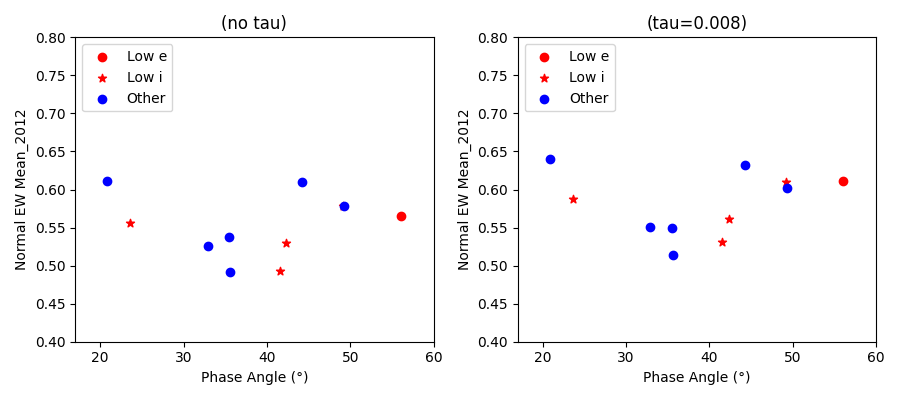

In [27]:
print('** USING 2012 ORIGINAL DATA **')
_=compare_tau_no_tau_60(commondata, col='Normal EW Mean_2012', use_2012_limits=True)

NO TAU:
Mean Normal EW low E/I: 0.544
Mean Normal EW Other:   0.559
Ratio:                       0.974


Mean Normal EW low E/I: 0.707
Mean Normal EW Other:   0.656
Ratio:                       1.078

Overall Tau/no-Tau ratio: 1.230


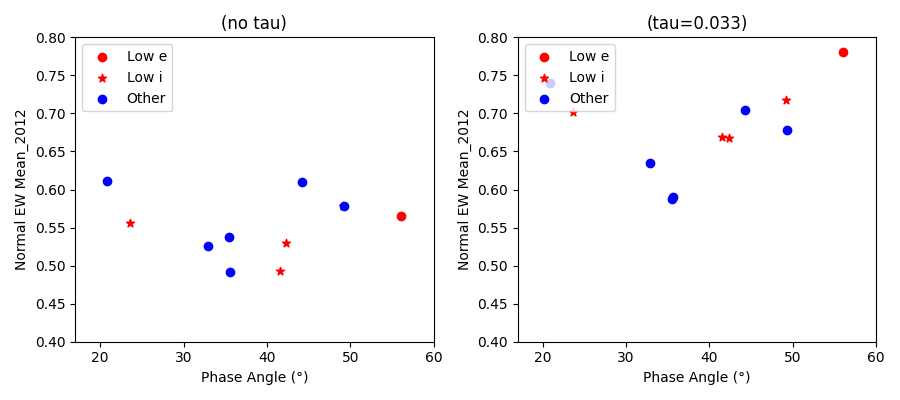

In [29]:
_=compare_tau_no_tau_60(commondata, col='Normal EW Mean_2012', use_2012_limits=True, best_tau=0.033)

# 2. Reproduce Figure 6a Using Calibration-Adjusted Measurements of 2012 Data Means; Compute Tau

USING 2012 ORIGINAL DATA ADJUSTED FOR KNOWN CALIBRATION CHANGES
NO TAU:
Mean Normal EW low E/I: 0.528
Mean Normal EW Other:   0.523
Ratio:                       1.010

BEST TAU: 0.000: Ratio 1.00981


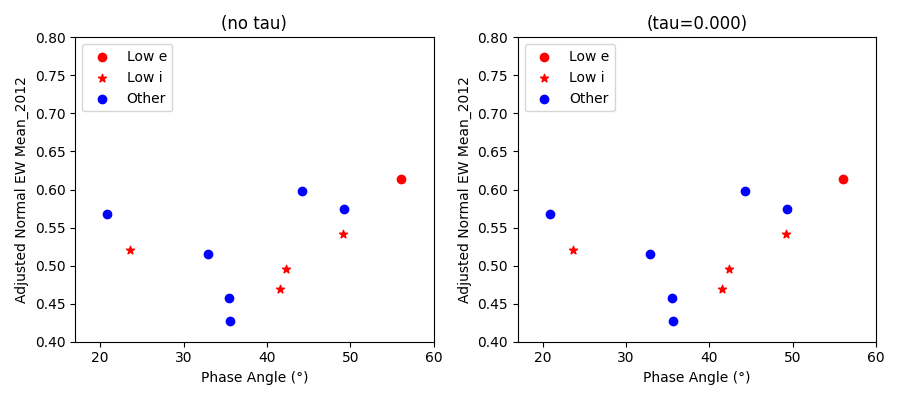

In [30]:
print('USING 2012 ORIGINAL DATA ADJUSTED FOR KNOWN CALIBRATION CHANGES')
_=compare_tau_no_tau_60(commondata, col='Adjusted Normal EW Mean_2012', use_2012_limits=True)

# 3. Reproduce Figure 6a Using New Data Means Limited to 2012 Observations; Compute Tau

USING NEW DATA LIMITED TO 2012 OBSERVATIONS
NO TAU:
Mean Normal EW low E/I: 0.525
Mean Normal EW Other:   0.513
Ratio:                       1.024

BEST TAU: 0.000: Ratio 1.02353


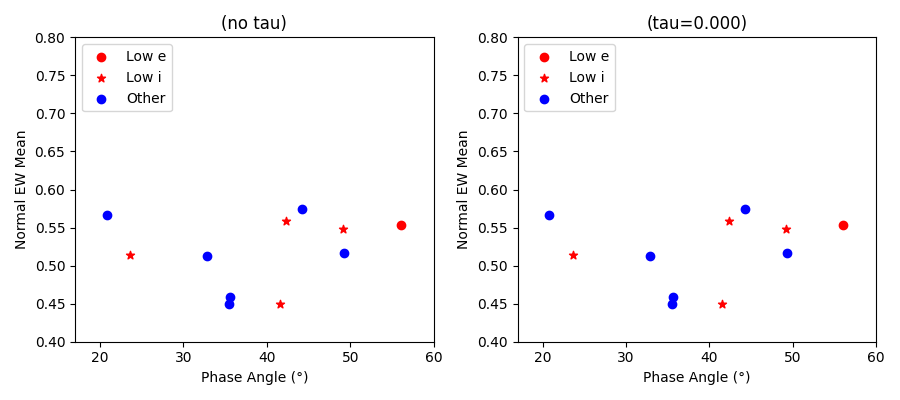

In [31]:
print('USING NEW DATA LIMITED TO 2012 OBSERVATIONS')
_=compare_tau_no_tau_60(commondata, use_2012_limits=True)

<div class="alert alert-info">
<h2>Summary</h2>
    
<b>The original data from 2012 prefers tau=0.008. tau=0.033 from F2012 doesn't work as well. However, when it is corrected for known calibration changes, this drops to tau=0.001. Using the new data for the same set of observations reduces this further to tau=0.000.</b>

<b>There is only a single observation in the CISSCAL 3.3 range (ISS_006RI) so we wouldn't actually expect the results of steps 1 and 2 to be very different; they are only corrected by the per-image calibration measurements. However, our measurements of CISSCAL 3.3 and 3.6 per-image calibration factor are not very precise. This is further shown in the fact that the results of steps 2 and 3 do not agree, even though we would expect them to.</b>
    
<b>Given that the new measurements result in tau=0.000, it appears that the higher values of tau were the result of calibration issues, not the result of actual observational differences.</b>
    
</div>

# 4. Reproduce Figure 6a Using ALL New Data Means; Compute Tau

USING ALL NEW LOW-PHASE DATA
NO TAU:
Mean Normal EW low E/I: 0.518
Mean Normal EW Other:   0.608
Ratio:                       0.851

BEST TAU: 0.018: Ratio 1.00263

Mean Normal EW low E/I: 0.642
Mean Normal EW Other:   0.644
Ratio:                       0.997

Overall Tau/no-Tau ratio: 1.135


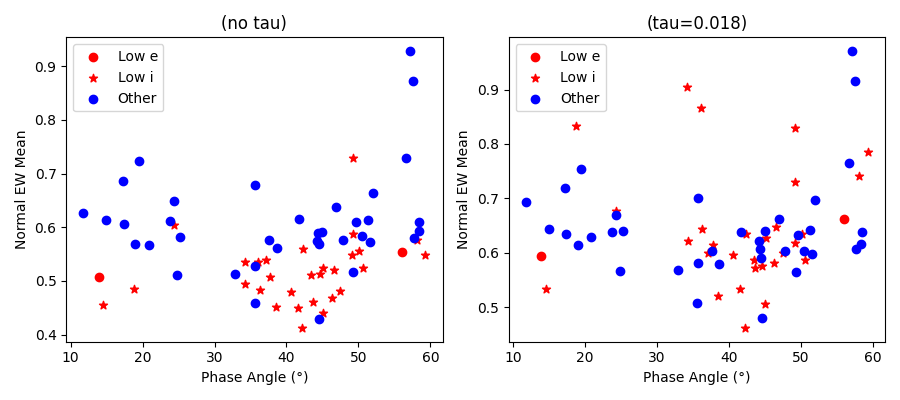

In [35]:
print('USING ALL NEW LOW-PHASE DATA')
best_low_phase_tau = compare_tau_no_tau_60(obsdata_60_0)

# 4a. Reproduce Figure 6a Using ALL New Data Medians; Compute Tau

USING ALL NEW LOW-PHASE DATA MEDIANS
NO TAU:
Mean Normal EW low E/I: 0.504
Mean Normal EW Other:   0.574
Ratio:                       0.878

BEST TAU: 0.015: Ratio 1.00178

Mean Normal EW low E/I: 0.604
Mean Normal EW Other:   0.603
Ratio:                       1.002

Overall Tau/no-Tau ratio: 1.112


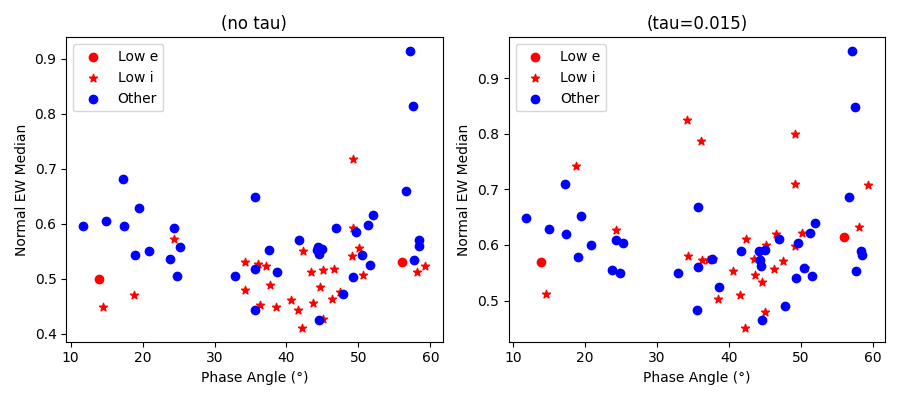

In [37]:
print('USING ALL NEW LOW-PHASE DATA MEDIANS')
best_low_phase_tau = compare_tau_no_tau_60(obsdata_60_0, col='Normal EW Median')

# 5. Reproduce Figure 6a Using ALL New Data 1-Degree Slices; Compute Tau

USING ALL NEW LOW-DATA DATA WITH 1-DEGREE SLICES
NO TAU:
Mean Normal EW low E/I: 0.529
Mean Normal EW Other:   0.582
Ratio:                       0.909

BEST TAU: 0.012: Ratio 1.00156

Mean Normal EW low E/I: 0.606
Mean Normal EW Other:   0.607
Ratio:                       0.998

Overall Tau/no-Tau ratio: 1.086


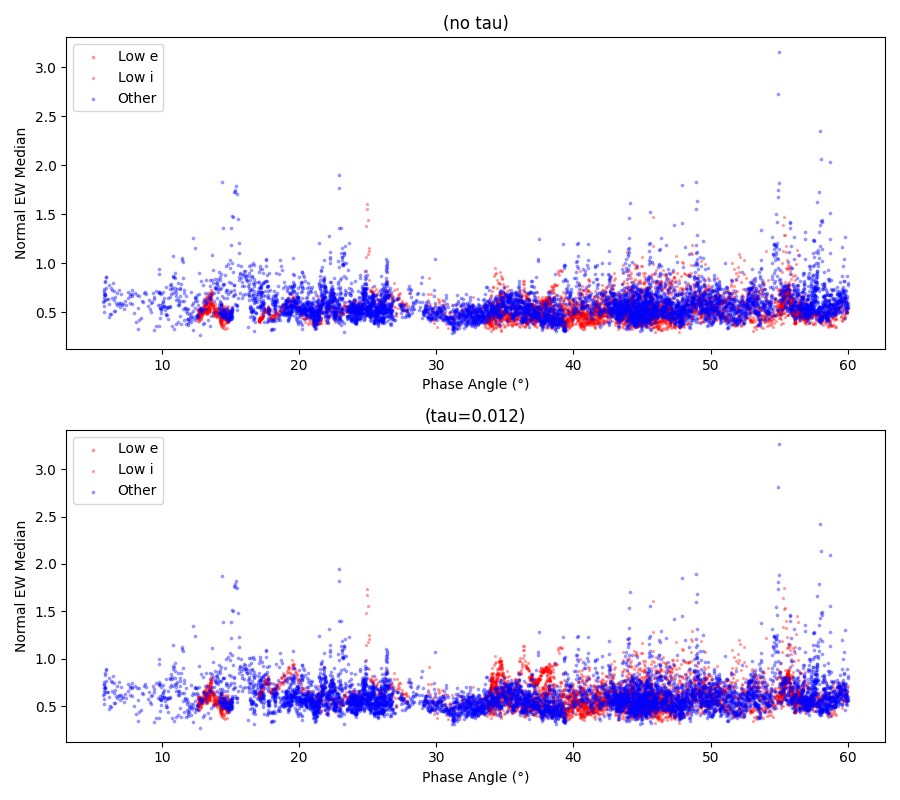

In [38]:
print('USING ALL NEW LOW-DATA DATA WITH 1-DEGREE SLICES')
_=compare_tau_no_tau_60(obsdata_0_1, small_plot=True, col='Normal EW Median')

# 6. Reproduce Figure 6a Using ALL New Data Means (e,i < 86); Compute Tau

USING ALL NEW LOW-PHASE DATA
NO TAU:
Mean Normal EW low E/I: 0.527
Mean Normal EW Other:   0.608
Ratio:                       0.866

BEST TAU: 0.035: Ratio 1.00138

Mean Normal EW low E/I: 0.679
Mean Normal EW Other:   0.680
Ratio:                       0.999

Overall Tau/no-Tau ratio: 1.162


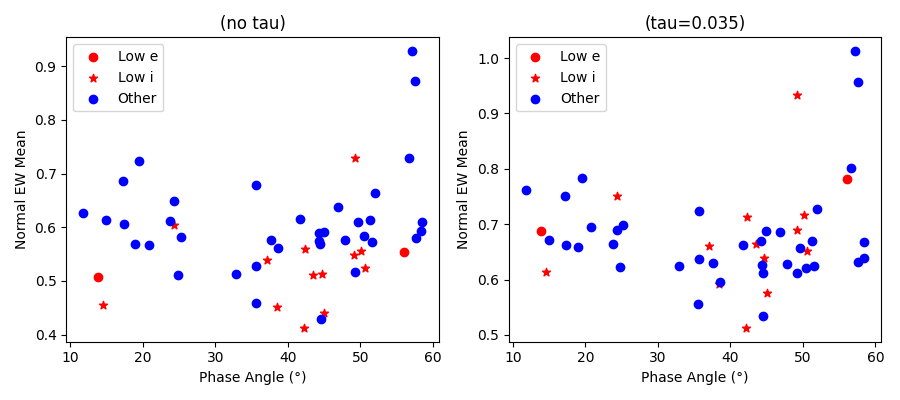

In [41]:
print('USING ALL NEW LOW-PHASE DATA')
high_ei_obsdata_60_0 = obsdata_60_0[((obsdata_60_0['Mean Emission']-90).abs() >= 4) & ((obsdata_60_0['Incidence']-90).abs() >= 4)]
high_ei_obsdata_0_1 = obsdata_0_1[((obsdata_0_1['Mean Emission']-90).abs() >= 4) & ((obsdata_0_1['Incidence']-90).abs() >= 4)]
best_low_phase_high_ei_tau = compare_tau_no_tau_60(high_ei_obsdata_60_0)

# 6a. Reproduce Figure 6a Using ALL New Data Medians (e,i < 86); Compute Tau

USING ALL NEW LOW-PHASE DATA MEDIANS
NO TAU:
Mean Normal EW low E/I: 0.515
Mean Normal EW Other:   0.574
Ratio:                       0.897

BEST TAU: 0.027: Ratio 1.00113

Mean Normal EW low E/I: 0.627
Mean Normal EW Other:   0.626
Ratio:                       1.001

Overall Tau/no-Tau ratio: 1.124


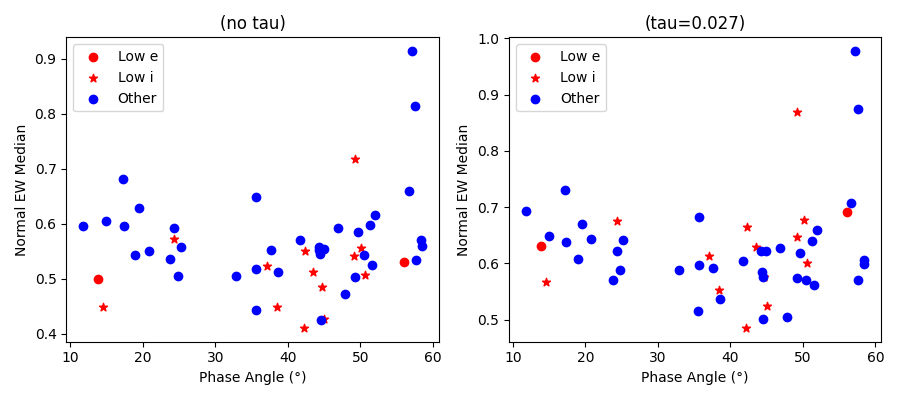

In [44]:
print('USING ALL NEW LOW-PHASE DATA MEDIANS')
high_ei_obsdata_60_0 = obsdata_60_0[((obsdata_60_0['Mean Emission']-90).abs() >= 4) & ((obsdata_60_0['Incidence']-90).abs() >= 4)]
high_ei_obsdata_0_1 = obsdata_0_1[((obsdata_0_1['Mean Emission']-90).abs() >= 4) & ((obsdata_0_1['Incidence']-90).abs() >= 4)]
best_low_phase_high_ei_tau = compare_tau_no_tau_60(high_ei_obsdata_60_0, col='Normal EW Median')

# 7. Reproduce Figure 6a Using ALL New Data 1-Degree Slices (e,i < 86); Compute Tau

USING ALL NEW LOW-DATA DATA WITH 1-DEGREE SLICES
NO TAU:
Mean Normal EW low E/I: 0.552
Mean Normal EW Other:   0.587
Ratio:                       0.940

BEST TAU: 0.017: Ratio 1.00146

Mean Normal EW low E/I: 0.625
Mean Normal EW Other:   0.624
Ratio:                       1.001

Overall Tau/no-Tau ratio: 1.083


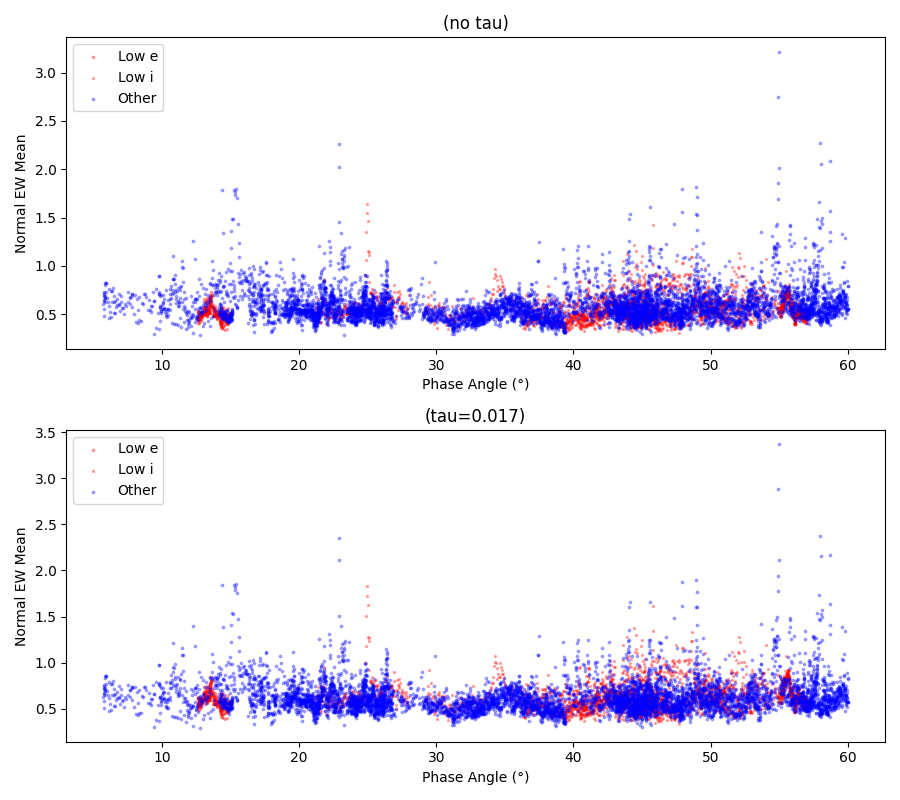

In [45]:
print('USING ALL NEW LOW-DATA DATA WITH 1-DEGREE SLICES')
_=compare_tau_no_tau_60(high_ei_obsdata_0_1, small_plot=True)

<div class="alert alert-info">
<h2>Summary</h2>
    
<b>Using all available low-phase data, there is a preference for tau=0.018 or 0.015. However, while this does make the means of the two data sets equal, the amount of scatter in the low-e/i group increases dramatically. This implies that this is not actually a good choice for tau, because ideally we would like the amount of scatter to decrease. Looking at the data points that change the most, they appear to be primarily at incidence angles very close to 90. This implies that the Chandrasekhar formula is not doing a good job of manipulating data at those extremes.</b>
    
<b>Repeating the experiment with observations within 4 degrees of the ring plane removed, we see the scatter of the tau-adjusted points remain controlled, with preferred taus of 0.024 and 0.017. In the worst case, these result in an increase in brightness of ~12%.</b>
</div>

# 8. Optimize Tau and Phase Curve Using ALL New Data Means

NO TAU:
g1 =  0.685 / scale1 =  1.605 / weight1 = 0.614 
g2 =  0.043 / scale2 =  1.010 / weight2 = 0.386  Avg scale 1.308

BEST TAU: 0.002
g1 =  0.686 / scale1 =  1.614 / weight1 = 0.611 
g2 =  0.043 / scale2 =  1.026 / weight2 = 0.389  Avg scale 1.320
Base std: 0.0607241
Best std: 0.0599040
Best/no tau ratio: 1.011


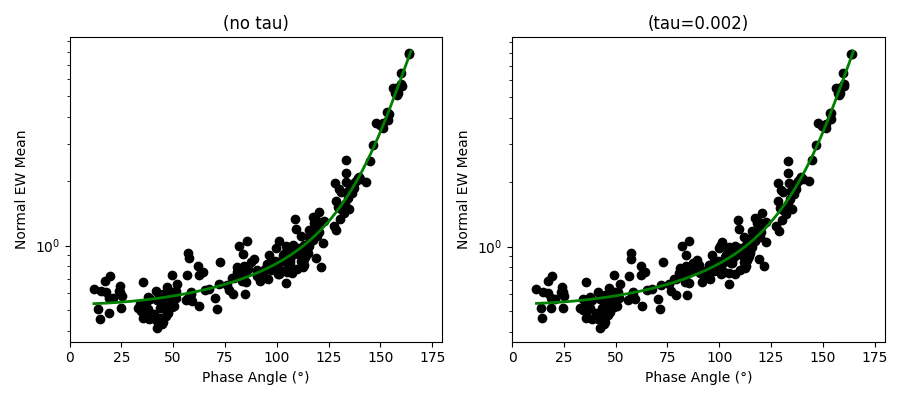

In [14]:
_=optimize_phase_tau(obsdata_60_0)

# 9. Optimize Tau and Phase Curve Using ALL New Data 1-Degree Slices

NO TAU:
g1 =  0.667 / scale1 =  1.603 / weight1 = 0.632 
g2 =  0.030 / scale2 =  0.934 / weight2 = 0.368  Avg scale 1.268

BEST TAU: 0.001
g1 =  0.668 / scale1 =  1.601 / weight1 = 0.628 
g2 =  0.033 / scale2 =  0.949 / weight2 = 0.372  Avg scale 1.275
Base std: 0.1109247
Best std: 0.1106176
Best/no tau ratio: 1.006

FORCE TAU: 0.015
g1 =  0.682 / scale1 =  1.613 / weight1 = 0.591 
g2 =  0.048 / scale2 =  1.118 / weight2 = 0.409  Avg scale 1.365
Force std: 0.1268379
Force/no tau ratio: 1.114


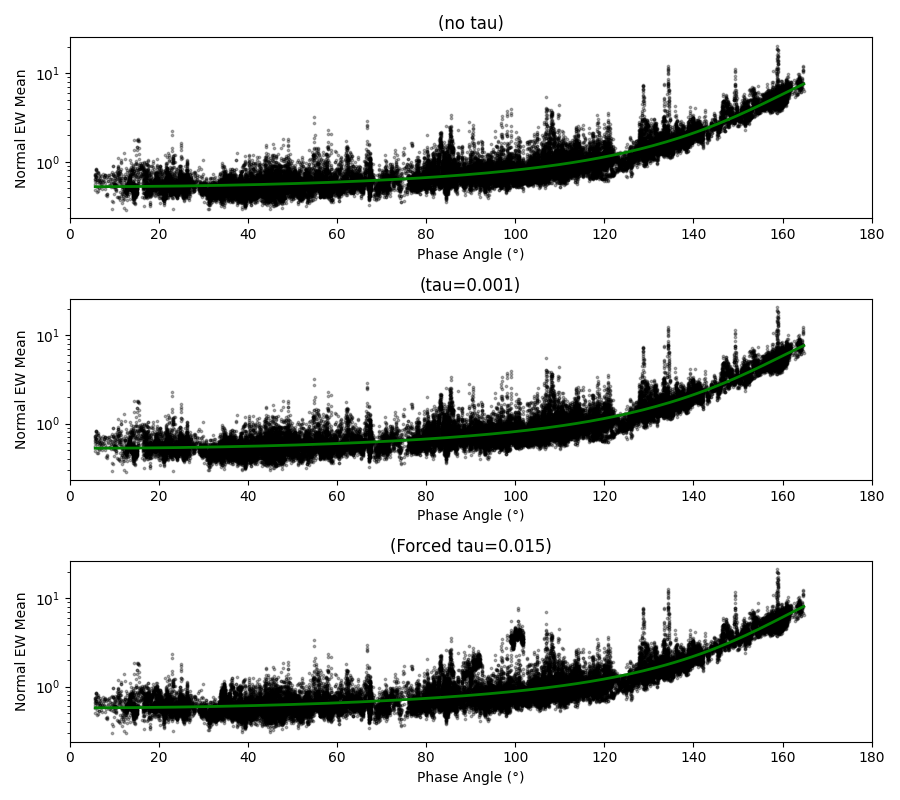

In [15]:
_=optimize_phase_tau(obsdata_0_1, small_plot=True, force_tau=best_low_phase_tau)

<div class="alert alert-info">
<h2>Summary</h2>
    
<b>Optimizing tau for the entire data set, we find a preference for tau=0.001 or 0.002, both of which are negligible. Forcing tau to be 0.013, the best found for low phase, causes a significant reduction in goodness of fit to the phase curve.</b>
</div>

# 10. Optimize Tau and Phase Curve Using ALL New Data Means (e,i < 86)

In [16]:
high_ei_obsdata_60_0 = obsdata_60_0[((obsdata_60_0['Mean Emission']-90).abs() >= 4) & ((obsdata_60_0['Incidence']-90).abs() >= 4)]
high_ei_obsdata_0_1 = obsdata_0_1[((obsdata_0_1['Mean Emission']-90).abs() >= 4) & ((obsdata_0_1['Incidence']-90).abs() >= 4)]

NO TAU:
g1 =  0.683 / scale1 =  1.631 / weight1 = 0.618 
g2 =  0.027 / scale2 =  1.007 / weight2 = 0.382  Avg scale 1.319

BEST TAU: 0.009
g1 =  0.679 / scale1 =  1.690 / weight1 = 0.624 
g2 =  0.016 / scale2 =  1.017 / weight2 = 0.376  Avg scale 1.354
Base std: 0.0613538
Best std: 0.0591860
Best/no tau ratio: 1.029


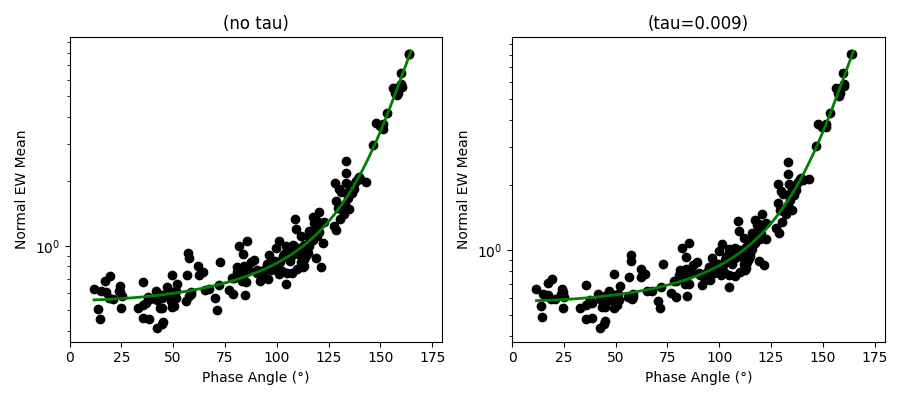

In [17]:
_=optimize_phase_tau(high_ei_obsdata_60_0)

# 11. Optimize Tau and Phase Curve Using ALL New Data 1-Degree Slices (e,i < 86)

NO TAU:
g1 =  0.667 / scale1 =  1.607 / weight1 = 0.629 
g2 =  0.024 / scale2 =  0.947 / weight2 = 0.371  Avg scale 1.277

BEST TAU: 0.009
g1 =  0.664 / scale1 =  1.664 / weight1 = 0.634 
g2 =  0.013 / scale2 =  0.960 / weight2 = 0.366  Avg scale 1.312
Base std: 0.1124970
Best std: 0.1116036
Best/no tau ratio: 1.031

FORCE TAU: 0.015
g1 =  0.662 / scale1 =  1.702 / weight1 = 0.637 
g2 =  0.005 / scale2 =  0.969 / weight2 = 0.363  Avg scale 1.336
Force std: 0.1111883
Force/no tau ratio: 1.052


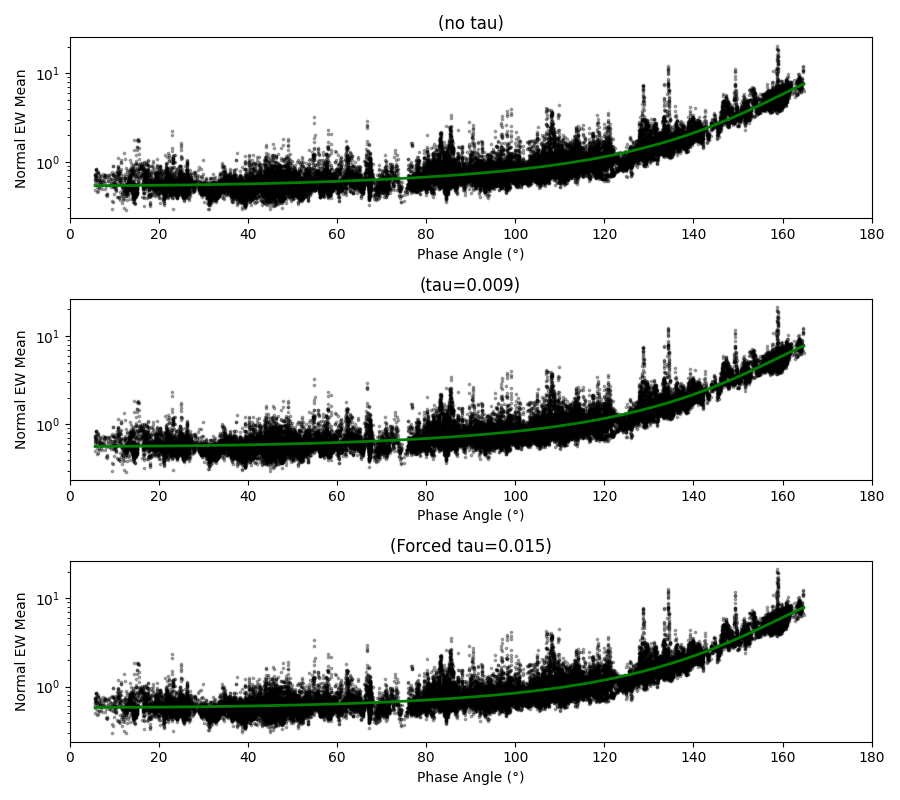

In [18]:
_=optimize_phase_tau(high_ei_obsdata_0_1, small_plot=True, force_tau=best_low_phase_tau)

<div class="alert alert-info">
<h2>Summary</h2>
    
<b>Removing very low incidence and emission angle observations, the preferred tau=0.009 with a change in brightness from tau=0 of only 3%, vs. tau=0.013 with a change of brightness of only 4%. Since, with the complete data set, the change in brightness at tau=0.013 is 10%, this shows that most of the change in brightness is caused by a small number of low-incidence and low-emission angle observations. We should consider removing these observations from our photometry dataset entirely.</b>
</div>

# 12. Plot EW / Phase Curve vs. Mu and Mu0 for 1-Degree Slices and ALL Phase Angles

In [55]:
cutoff1 = 25
cutoff2 = None
obsdata_limited = limit_by_quant(obsdata_0_1, cutoff1, cutoff2)
params_limited, _, _ = fit_hg_phase_function(2, None, obsdata_limited)
print(f'1 degree slices, cutoff {cutoff1} / {cutoff2}')
print_hg_params(params_limited)

1 degree slices, cutoff 25 / None
g1 =  0.674 / scale1 =  1.359 / weight1 = 0.661 
g2 =  0.008 / scale2 =  0.696 / weight2 = 0.339  Avg scale 1.027


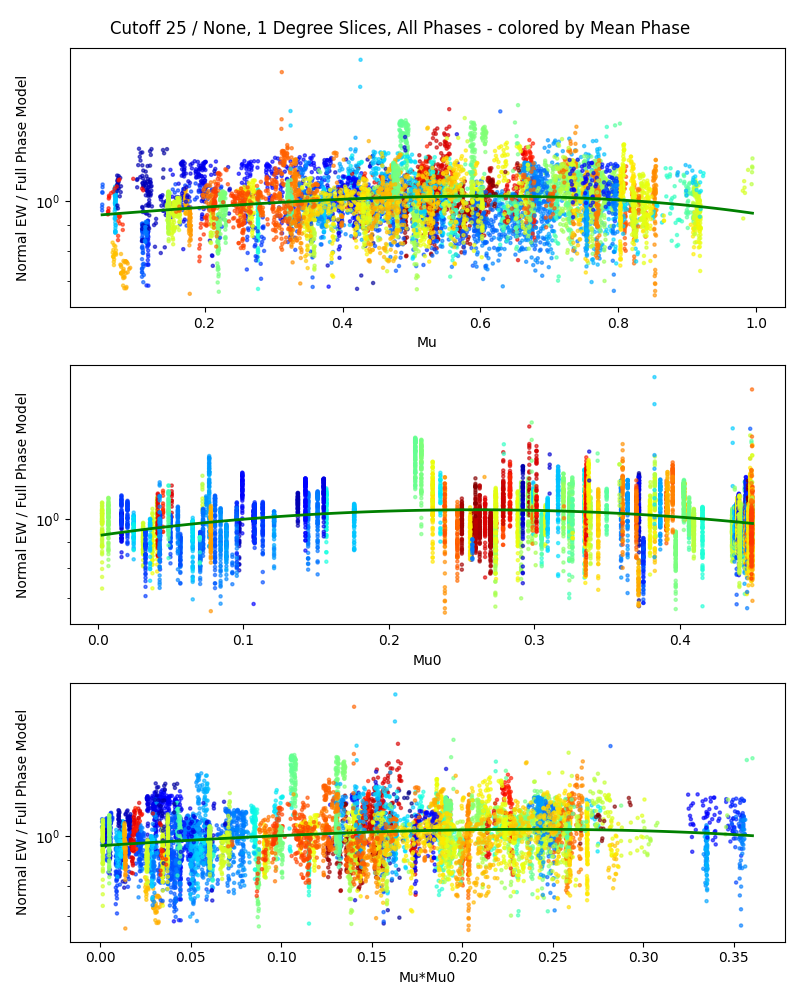

In [56]:
plot_ratio_vs_mu_mu0(obsdata_limited, params_limited, 
                     f'Cutoff {cutoff1} / {cutoff2}, 1 Degree Slices, All Phases', order=3)

# 13. Plot EW / Phase Curve vs. Mu and Mu0 for 1-Degree Slices and Phase Angles < 60

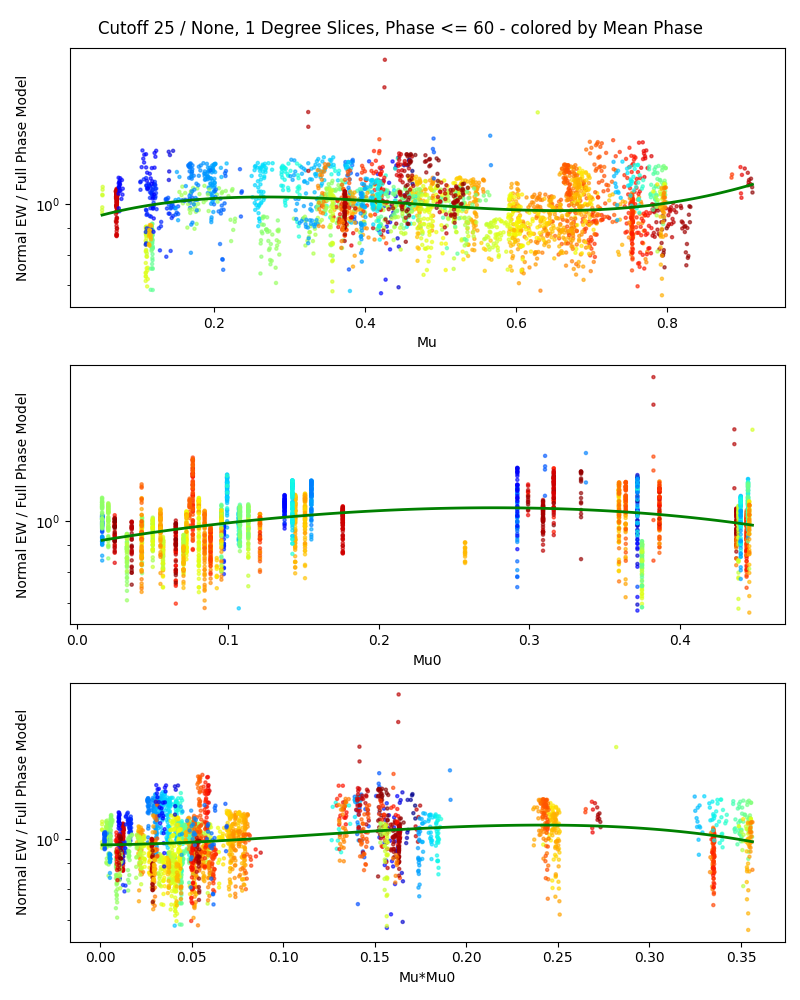

In [57]:
obsdata_limited_low_phase = obsdata_limited[obsdata_limited['Mean Phase'] <= 60].copy()
plot_ratio_vs_mu_mu0(obsdata_limited_low_phase, params_limited, 
                     f'Cutoff {cutoff1} / {cutoff2}, 1 Degree Slices, Phase <= 60', order=3)

<div class="alert alert-info">
<h2>Summary</h2>
    
<b>We do not see a compelling trend in phase-normalized brightness with either Mu or Mu0.</b>
</div>

# 14. Conclusion

<div class="alert alert-info">
<h2>Conclusion</h2>
    
<b>Evidence for the need for a tau-adjustment is inconsistent. Values of tau that improve low-phase (less than 60 degrees) observations increase scatter when looking at all phase angles. Optimizations of tau while fitting a phase curve result in very low values for tau (<= 0.002). Using phase-normalized EWs, there are no obvious trends of brightness with either Mu or Mu0.</b>
    
<b>As a result, we conclude that an adjustment for tau is not necessary, or at the very least that our adjustment model is insufficient to handle the data we have. It is possible a more sophisticated model would do a better job. We choose to not do any adjustment, and accept that the resulting brightness values may be in error on the order of 10%.</b>
</div>